It is inherently difficult to generate ideal images with a single model due to not being able to capture all the ranges of photons by a single GAP model

The next experiment will study the utilization of cascaded models for inpainting task

    if it works for inpainting 
    
    it will work for colorization

    it will work for super resolution


In [106]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

if not torch.cuda.is_available():
    raise ValueError("GPU not found, code will run on CPU and can be extremely slow!")
else:
    device = torch.device("cuda:0")

import time
from glob import glob
import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping
import torch.optim as optim
import torch.utils.data as dt

import os
os.chdir('/mnt/c/Users/ankit/Desktop/Msc AIML/msc-project/GAP/gap')
from GAP_UNET_ResBlock_ffhq import UN
from BinomDataset_ffhq_inpaint_noaug import BinomDataset
from DataFolderFFHQ import DataFolder
from inferencev3 import sample_image
from tasks import inpainting
from utils import preprocess, stats, stack_video

Exception ignored in: <function _xla_gc_callback at 0x7f3c0c01bbe0>
Traceback (most recent call last):
  File "/home/ankith/anaconda3/envs/rsenv/lib/python3.10/site-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 


In [3]:
name = 'm40tom32.5-512x512-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade'

model1 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

In [4]:
name = 'm40to30-512x512-ffhq-inpainting-noaug'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models'

model = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

In [241]:
ffhq_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/ffhq/faces/'
minpsnr = -40
maxpsnr = -32.5
dataset = BinomDataset(ffhq_path, windowSize = 256, minPSNR = minpsnr, maxPSNR= maxpsnr, virtSize= 1, imgsize= 256, masksize= 128)

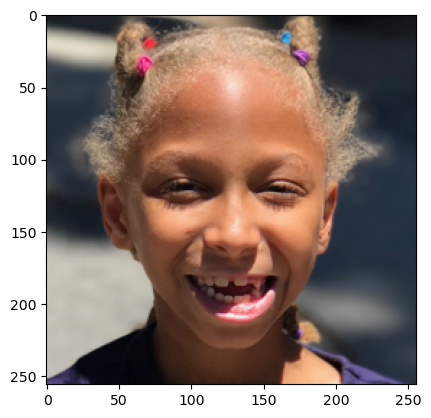

In [246]:
img = dataset[0]
plt.imshow(preprocess(img[:3]))

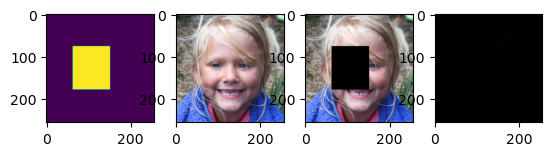

In [255]:
img = dataset[0]
plt.subplot(1, 4, 1)
plt.imshow(preprocess(img[3:4]))
plt.subplot(1, 4, 2)
plt.imshow(preprocess(img[:3]))
plt.subplot(1, 4, 3)
plt.imshow(preprocess(img[4:7]))
plt.subplot(1, 4, 4)
plt.imshow(preprocess(img[7:10]))

(-0.5, 511.5, 511.5, -0.5)

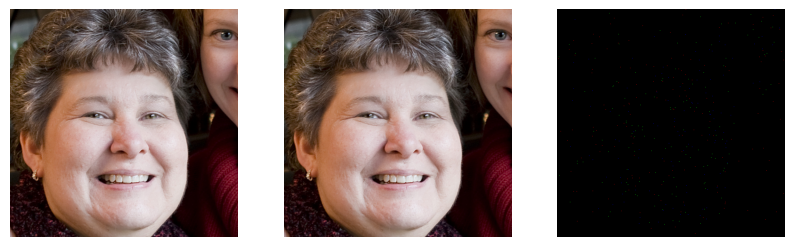

In [17]:
ffhq_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/ffhq/'
dataset = DataFolder(ffhq_path, minPSNR = -40, maxPSNR= 15)
dataTestGT, dataTestTarget, dataTest = dataset[3877]

plt.figure(figsize= (10, 10))
plt.subplot(1, 3, 1)
plt.imshow(preprocess(dataTestGT))
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(preprocess(dataTestTarget))
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(preprocess(dataTest))
plt.axis('off')


torch.Size([3, 512, 512])


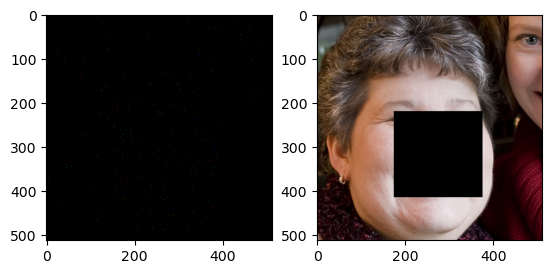

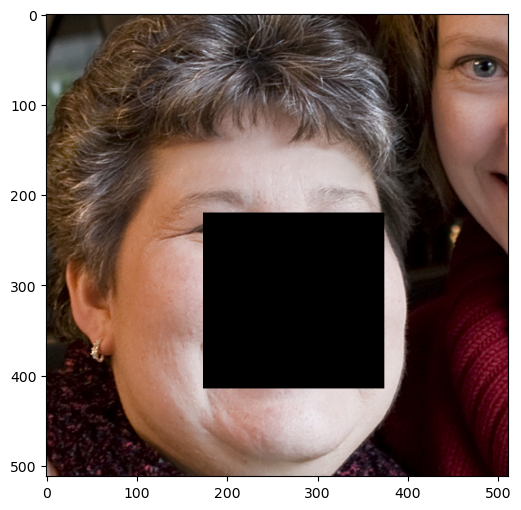

In [29]:
masks = inpainting(imgsize = 512, masksize = 200)
mask = masks.generate_mask().numpy()
test = dataTest 
testGT = dataTestGT/dataTestGT.mean()
cond_test = testGT * (1 - mask)
print(cond_test.shape)
plt.subplot(1, 2, 1)
plt.imshow(preprocess(test))
plt.subplot(1, 2, 2)
plt.imshow(preprocess(cond_test))
plt.figure(figsize= (6, 6))
plt.imshow(preprocess(cond_test))


torch.Size([3, 512, 512])


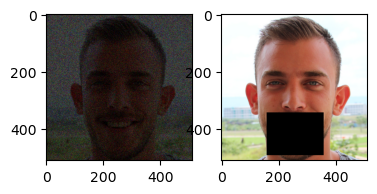

In [6]:
from skimage.draw import rectangle
mask = np.zeros((512, 512), dtype= np.float32)
start = (345, 160)
extent = (150, 200)
rr, cc = rectangle(start, extent=extent, shape=mask.shape)
mask[rr, cc] = 1
test = dataTest 
testGT = dataTestGT/dataTestGT.mean()
cond_test = testGT * (1 - mask)
print(cond_test.shape)
plt.subplot(1, 3, 1)
plt.imshow(preprocess(test))
plt.subplot(1, 3, 2)
plt.imshow(preprocess(cond_test))
mask = mask[None]

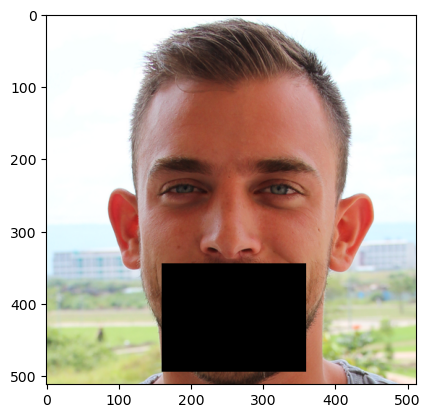

In [16]:
plt.imshow(preprocess(cond_test))


In [48]:
cond_test.dtype, mask.dtype

(torch.float32, dtype('float32'))

torch.Size([3, 512, 512])
torch.Size([1, 4, 512, 512])
torch.Size([3, 512, 512])
input shape : torch.Size([1, 7, 512, 512]), model input shape : torch.Size([1, 1, 7, 512, 512])
tensor(255.) tensor(0.) tensor(69.1661) 255.0 103.0
inp shape : torch.Size([3, 512, 512])
out shape : torch.Size([1, 3, 512, 512])
gt shape : torch.Size([3, 512, 512])


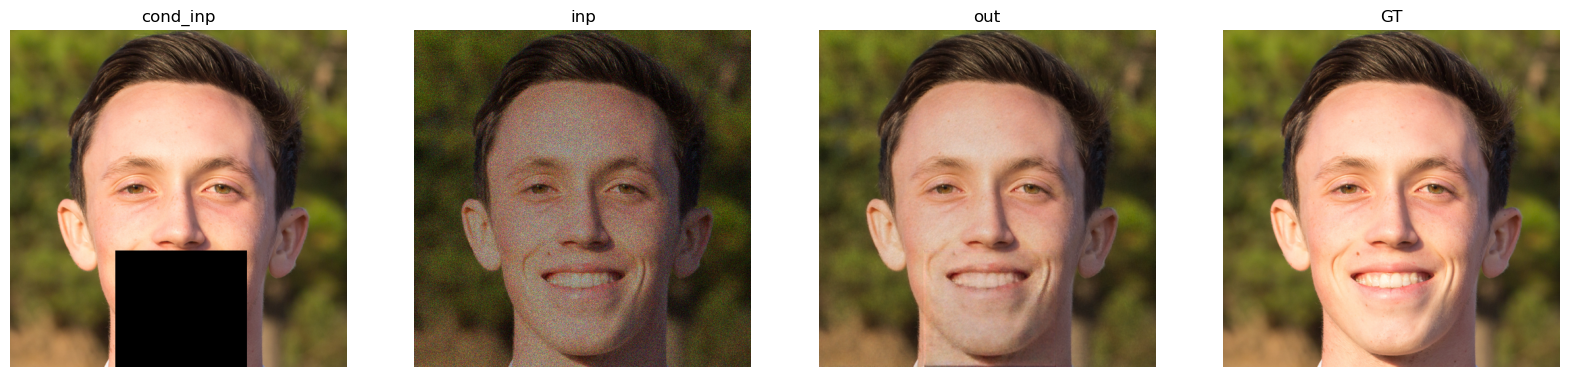

In [49]:
cond_input = torch.from_numpy(np.expand_dims(np.concatenate((mask, cond_test), axis = 0), axis = 0))
# dataTest = torch.zeros_like(dataTest)
for inp, cinp, gt in zip(dataTest[None], cond_input[None], dataTestGT[None]): 
    print(inp.shape) 
    print(cinp.shape) 
    print(gt.shape) 

    inpT = (inp).to(device) 
    cond_inpT = cinp.to(device)
    inpT = torch.cat([cond_inpT, inpT[None]], dim = 1).to(device)
    print(f'input shape : {inpT.shape}, model input shape : {inpT[None].shape}')
    y = model(inpT).detach().cpu()
    out = np.exp(y)

    out = inp.sum() * out / out.sum() 
    
    print(gt.max(), gt.min(), gt.std(), np.percentile(gt,99.9), np.percentile(gt,50))

    inp = inp/inp.mean()
    out = out/out.mean()
    gt = gt/gt.mean()
    inp = inp/inp.max()
    out = out/out.max()
    gt = gt/gt.max()
    # cond_inp = cinp[1]/cinp[1].mean()

    
    print(f'inp shape : {inp.shape}')
    print(f'out shape : {out.shape}')
    print(f'gt shape : {gt.shape}')

    cond_vmax = np.percentile(cond_test,99.9)
    plt.figure(figsize=(20,20))
    plt.subplot(1, 4, 1)
    plt.imshow(preprocess(cond_test) ,vmin = 0, vmax = cond_vmax)
    plt.title('cond_inp')
    plt.axis('off')

    vmax = np.percentile(gt,99.9)
    plt.subplot(1, 4, 2)
    plt.imshow(inp.permute(1, 2, 0),vmin = 0, vmax = vmax)
    plt.title('inp')
    # plt.show()
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.imshow(out[0].permute(1, 2, 0),vmin = 0,vmax = vmax)
    plt.title('out')
    # plt.show()
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(gt.permute(1, 2, 0),vmin = 0,vmax = vmax)
    plt.title('GT')
    plt.axis('off')
    plt.show()
    


In [38]:
dataTest.sum()

tensor(134.)

In [7]:
name = 'm32.5tom25-512x512-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade'

model2 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

In [8]:
name = 'm25tom17.5-512x512-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade'

model3 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

In [9]:
name = 'm17.5tom10-512x512-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade'

model4 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

In [10]:
name = 'm10tom2.5-512x512-ffhq-inpainting-cascade-run2'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade'

model5 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

In [11]:
name = 'm2.5to5-512x512-ffhq-inpainting-cascade-run2'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade'

model6 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

In [12]:
name = '5to12.5-512x512-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade'

model7 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

cond_input shape torch.Size([1, 4, 512, 512])
cond_img shape torch.Size([1, 4, 512, 512])
input_img shape torch.Size([1, 7, 512, 512])
input_img shape torch.float32
(1, 3, 512, 512)


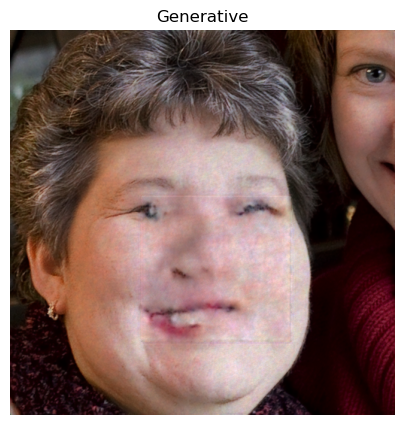

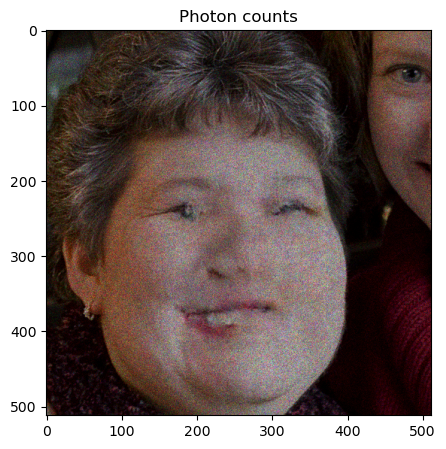

_______________________________________ 346
time (s): 118.41519904136658 time per image (s) 118.41519904136658


In [30]:
from inference_ffhq_cascade import sample_image
import matplotlib.image as mpimg
import time
import numpy as np

# We are starting with an image containing zeros,
# i.e., sampling from scratch

# we just have 1 channel
channels = 3
# we can sample multiple images at the same time in a batch
batch_size = 1
# for best results this should correspond to training pach size
pixels_x = 512
pixels_y = 512

inp_img =  torch.zeros(batch_size ,channels, pixels_y, pixels_x)
# inp_img = dataTest[None]
# masks2 = inpainting(imgsize = 512, masksize = 500)
# mask = masks2.generate_mask().numpy()
cond_input = torch.from_numpy(np.expand_dims(np.concatenate((mask, cond_test), axis = 0), axis = 0))
# cond_input = torch.from_numpy(np.expand_dims(np.concatenate((np.ones_like(mask), np.zeros_like(cond_test)), axis = 0), axis = 0))

print(f'cond_input shape {cond_input.shape}')

cond_img = cond_input
print(f'cond_img shape {cond_img.shape}')

# cond_img = torch.zeros_like(cond_img)
input_img = torch.cat((cond_img, inp_img), 1).to(device)
print(f'input_img shape {input_img.shape}')
print(f'input_img shape {input_img.dtype}')


for i in range(1):
    

    startTime = time.time()
    
    # sampling the image(s)
    denoised, photons, stack, iterations = sample_image(input_img,
                                                        [model1, model2, model3, model4, model5, model6, model7], 
                                                        beta = 0.005,
                                                        save_every_n = 10,
                                                        max_psnr = -33,
                                                        max_its = 50000000,
                                                        channels = 3)

    
    # In case we do multiple images in a batch, we show all of them.
    for j in range(denoised.shape[0]):
#         print(iterations)
            # print(denoised.shape)
            # plt.figure(figsize = (5,5))
            # plt.imshow(denoised[j].transpose(1, 2, 0), cmap='inferno', vmin = 0,
            #            vmax = np.percentile(denoised[j],99.99))
            # plt.title('Generative')
            # plt.axis('off')
            # plt.show()
            
            # plt.figure(figsize = (5,5))
            # plt.imshow(photons[j,0], cmap='inferno', vmin = 0,
            #            vmax = np.percentile(photons[j],99.99))
            # plt.title('Photon counts')
            # plt.show()
            denoised/=denoised.mean()
            print(denoised.shape)
            plt.figure(figsize = (5,5))
            plt.imshow(preprocess(denoised[0]), vmin = 0,
                       vmax = np.percentile(preprocess(denoised[0]),99.99))
            plt.title('Generative')
            plt.axis('off')
            plt.show()
            
            plt.figure(figsize = (5,5))
            plt.imshow(preprocess(photons[0]), vmin = 0,
                       vmax = np.percentile(preprocess(photons[0]),99.99))
            plt.title('Photon counts')
            plt.show()
            
            
    
    print('_______________________________________', iterations)
    
    
    
    
    endTime = time.time()
    elapsedTime = endTime - startTime
    print ('time (s):', elapsedTime, 'time per image (s)', elapsedTime/denoised.shape[0])
   

In [40]:
cond_test.shape

torch.Size([3, 512, 512])

Text(0.5, 1.0, 'Ground Truth')

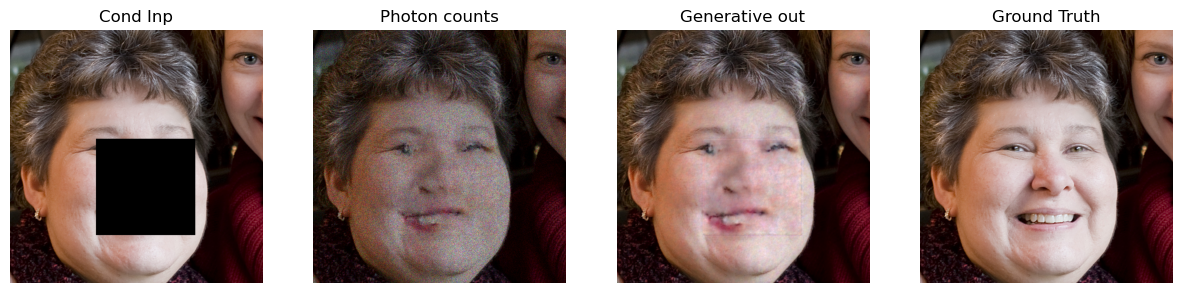

In [32]:
plt.figure(figsize=(15, 15))
plt.subplot(1, 4, 1)
plt.imshow(preprocess(cond_test))
plt.axis('off')
plt.title('Cond Inp')
plt.subplot(1, 4, 2)
plt.imshow(preprocess(photons[0]), vmin = 0,vmax = np.percentile(preprocess(photons[0]),99.99))
plt.axis('off')
plt.title('Photon counts')
plt.subplot(1, 4, 3)
plt.imshow(preprocess(denoised[0]), vmin = 0, vmax = np.percentile(preprocess(denoised[0]),99.99))
plt.title('Generative')
plt.axis('off')
plt.title('Generative out')
plt.subplot(1, 4, 4)
plt.imshow(preprocess(dataTestGT))
plt.axis('off')
plt.title('Ground Truth')


In [33]:
vidstack = []
for i in range(len(stack)):
    vidstack.append(stack[i][0])
file_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/msc-project/outputs/stack-videos/'
file_name = 'ffhq3.mp4'
stack_video(stack= vidstack, 
            filename= os.path.join(file_path, file_name),
            framerate = 20)

Video saved at /mnt/c/Users/ankit/Desktop/Msc AIML/msc-project/outputs/stack-videos/ffhq3.mp4 + v4


In [74]:
len(stack)

247

0
psnr : -40


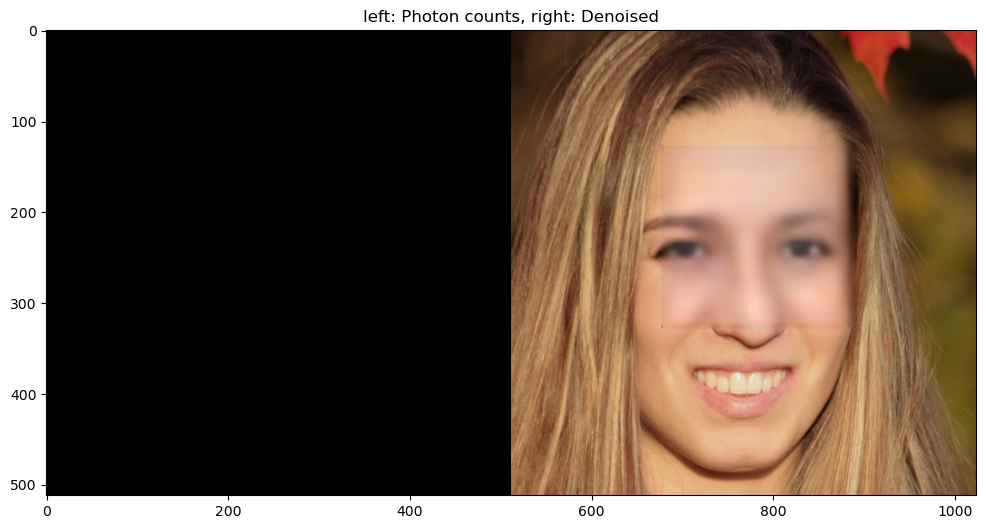

20
psnr : -35.83907299452624


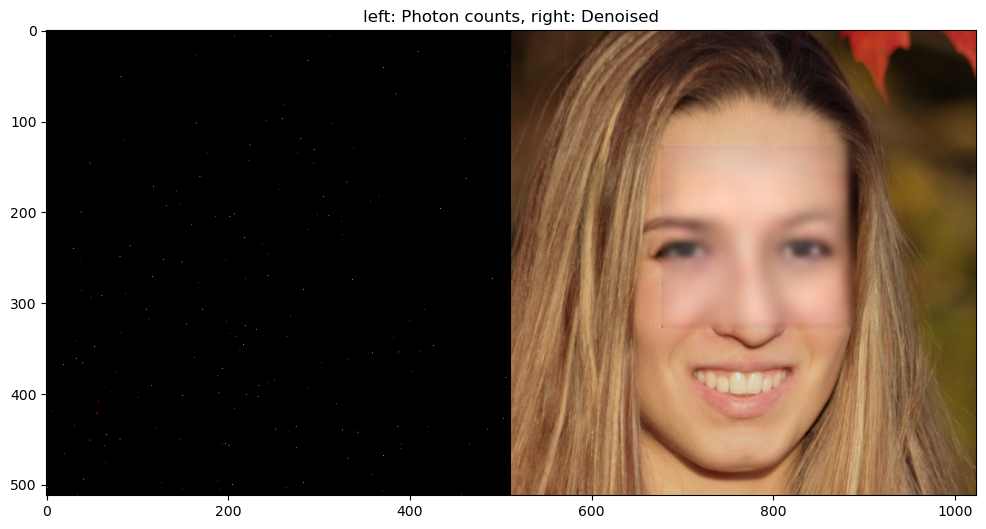

40
psnr : -31.06786060895907


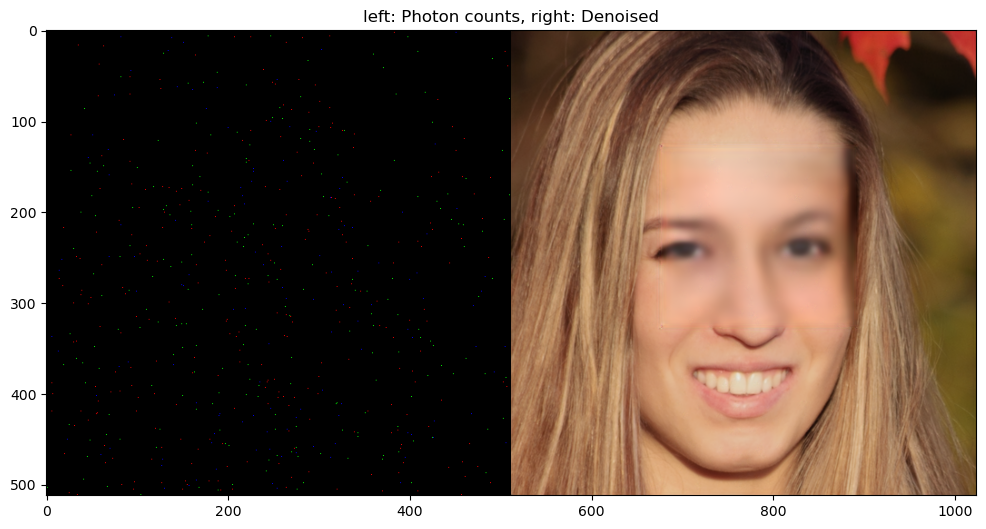

60
psnr : -26.808173124606803


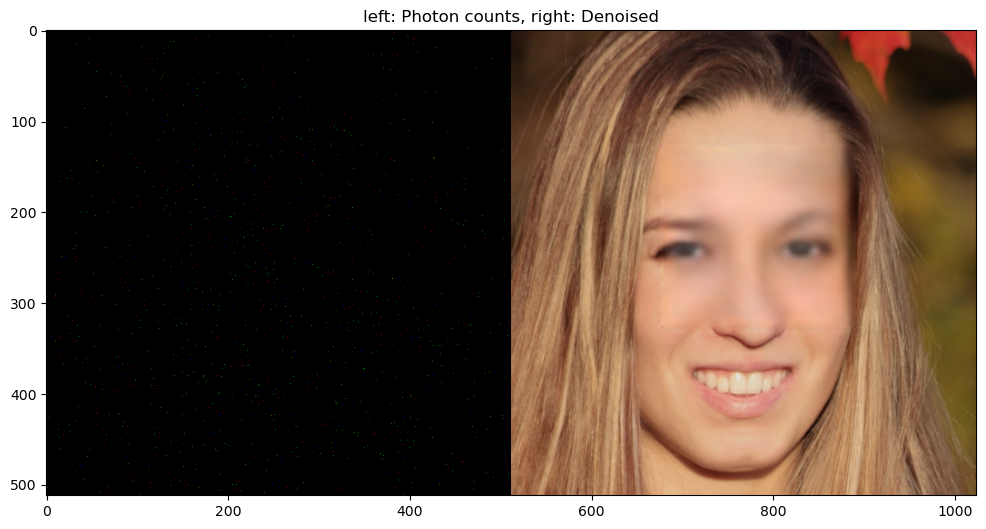

80
psnr : -22.542862072661535


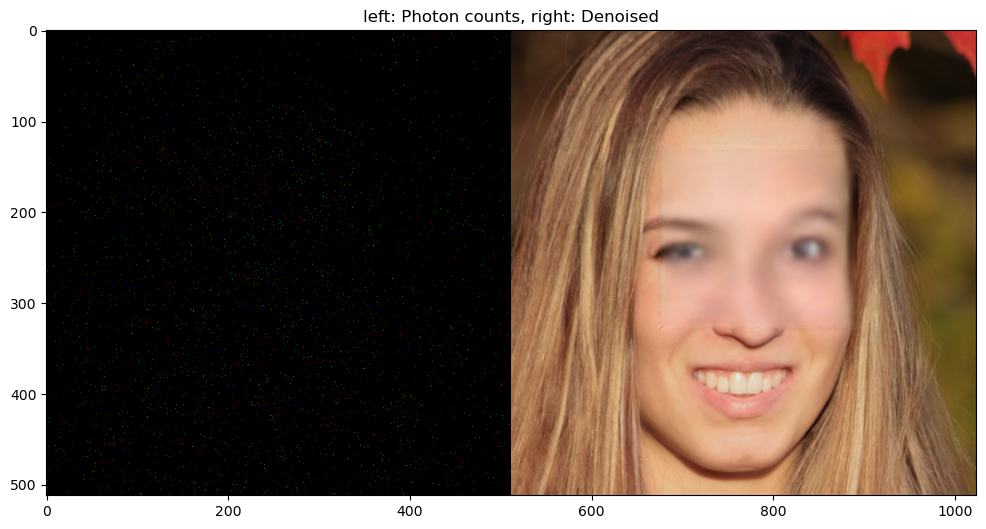

100
psnr : -18.289253813203953


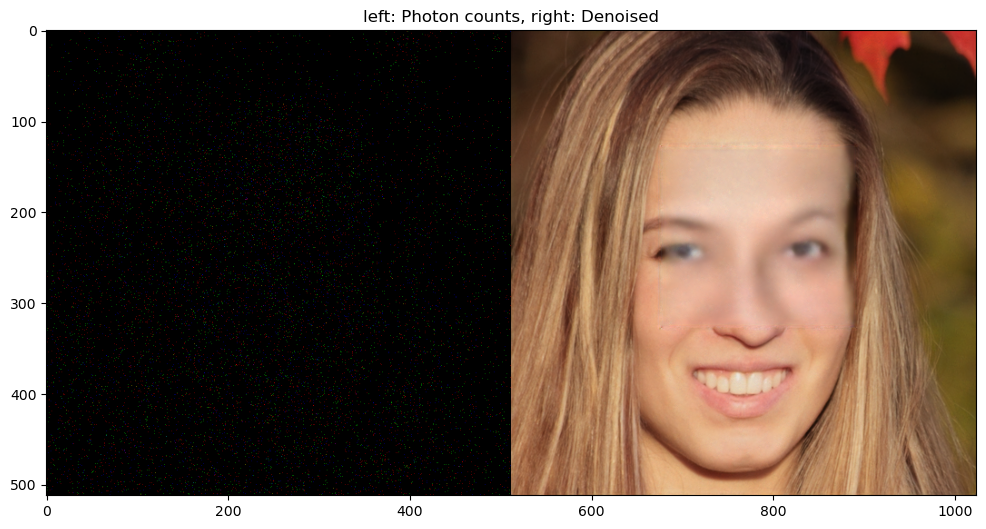

120
psnr : -14.077313244394551


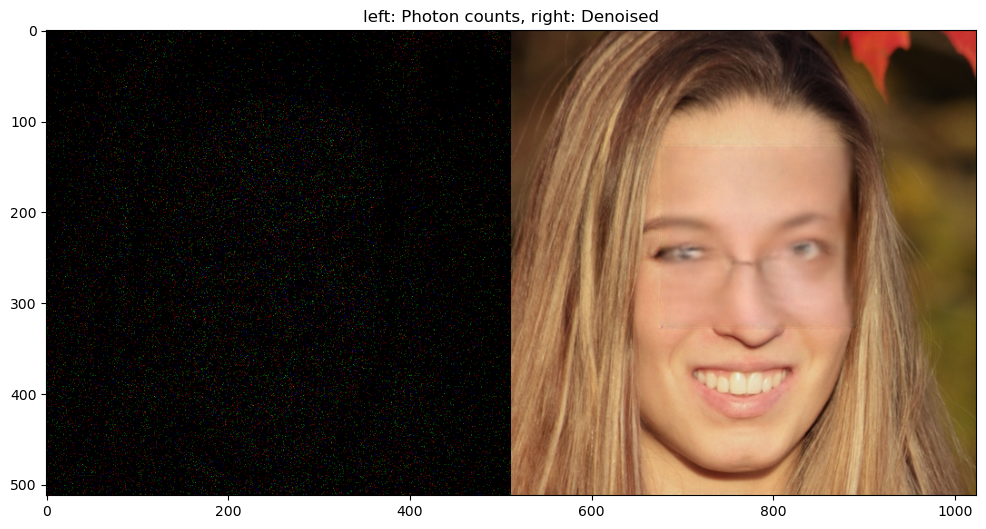

140
psnr : -9.770175960692677


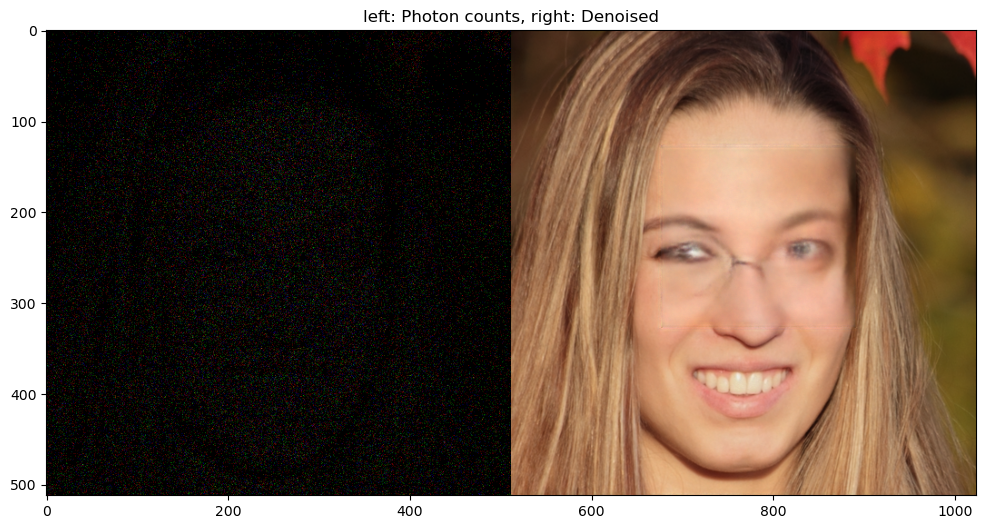

160
psnr : -5.422932063570563


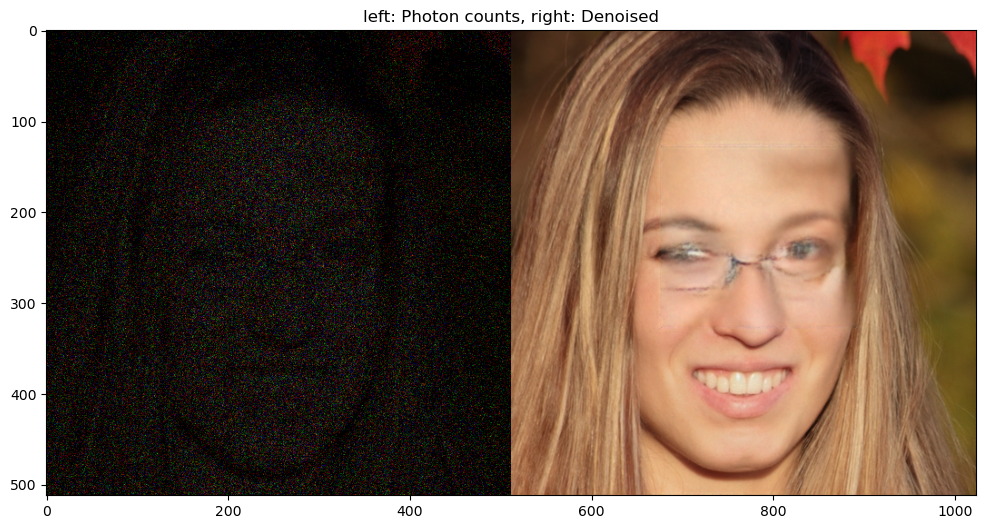

In [77]:
for i in range(len(stack)):
    if i%20 == 0 :
        im = (stack[i][0].transpose(1, 2, 0) * 255).astype(np.uint8)
        print(i)
        print(f'psnr : {stack[i][1]}')
        plt.figure(figsize = (12,12))
        plt.imshow(im, vmax = 0.9)
        plt.title('left: Photon counts, right: Denoised')
        plt.show()